# Tutorial: OLS Regression — Evaluation, Goodness of Fit & Hypothesis Testing

Building on last tutorial on linear regression, this tutorial covers:

1. **Recap of OLS** — closed-form solution, hat matrix
2. **Goodness of Fit** — RSS, TSS, MSS and R²
3. **Estimating Standard Errors** — $\hat{\sigma}^2$, $\text{SE}(\hat{\beta}_i)$, confidence intervals
4. **Hypothesis Testing** — t-statistic, p-values, rejecting $H_0$
5. **Application** using datasets



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

---
## Part 1 — Recap of OLS in Matrix Form

Given training samples $\{(x_i, y_i)\}_{i=1}^n$ we form:

$$X = \begin{bmatrix} 1 & x_{1,1} & \cdots & x_{1,p} \\ \vdots & & & \vdots \\ 1 & x_{n,1} & \cdots & x_{n,p} \end{bmatrix} \in \mathbb{R}^{n \times (p+1)}, \quad Y = \begin{bmatrix} y_1 \\ \vdots \\ y_n \end{bmatrix}$$

Why add column of ones?

OLS minimises the **Residual Sum of Squares**:
$$\text{RSS} = \|Y - X\beta\|^2$$

$$\hat{\beta} = (X^\top X)^{-1} X^\top Y$$

The **hat matrix** $H = X(X^\top X)^{-1} X^\top$ projects $Y$ onto the column space of $X$:
$$\hat{Y} = HY$$

### 1.1 Simple example: Generate data and fit OLS from scratch
Dummy example generated with noise to demonstrate OLS, data generated varies every iteration (seed not set), can evaluate estimated beta hat

In [2]:
# Generate simple 1D data: y = 2x + 1 + noise
n = 1000
x = np.linspace(0, 10, n)
noise = np.random.randn(n)
y = 2 * x + 1 + noise

# Train-test split
train_size = int(0.8 * n)
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build design matrix X with intercept column
X_train = np.column_stack([np.ones(len(x_train)), x_train])  # shape (n_train, 2)
X_test  = np.column_stack([np.ones(len(x_test)),  x_test])

# OLS closed-form solution
beta_hat = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
print(f"True coefficients  : intercept=1, slope=2")
print(f"Estimated beta_hat : intercept={beta_hat[0]:.4f}, slope={beta_hat[1]:.4f}")

True coefficients  : intercept=1, slope=2
Estimated beta_hat : intercept=0.9920, slope=2.0087


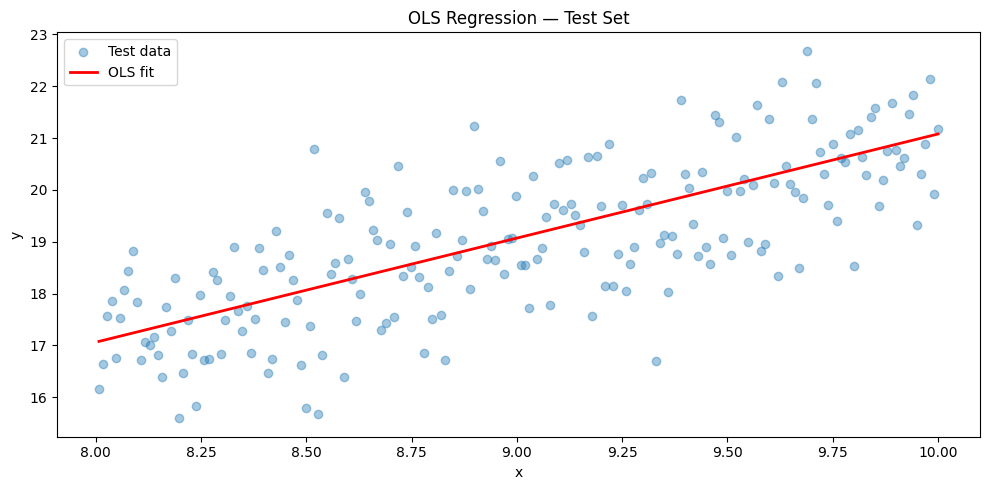

In [3]:
# Predictions and residuals
y_pred_train = X_train @ beta_hat
y_pred_test  = X_test  @ beta_hat

plt.figure(figsize=(10, 5))
plt.scatter(x_test, y_test, alpha=0.4, label='Test data')
plt.plot(x_test, y_pred_test, color='red', lw=2, label='OLS fit')
plt.xlabel('x'); plt.ylabel('y')
plt.title('OLS Regression — Test Set')
plt.legend(); plt.tight_layout(); plt.show()

Note : estimate beta using train, evaluate visually on test data

---
## Part 2 — Goodness of Fit: RSS, TSS, MSS and R²

We decompose the total variability in the output:

| Quantity | Formula | Meaning |
|---|---|---|
| **TSS** (Total Sum of Squares) | $\|Y - \bar{Y}\|^2 = \sum_i(y_i - \bar{y})^2$ | Inherent variability in $Y$ |
| **RSS** (Residual Sum of Squares) | $\|Y - \hat{Y}\|^2 = \sum_i(y_i - \hat{y}_i)^2$ | Mismatch between $Y$ and model |
| **MSS** (Model Sum of Squares) | $\|\hat{Y} - \bar{Y}\|^2 = \sum_i(\hat{y}_i - \bar{y})^2$ | Variability explained by the model |

**Key identity** (follows from Pythagoras, since $Y - \hat{Y} \perp$ col-space of $X$):
$$\text{TSS} = \text{MSS} + \text{RSS}$$

Note : $Y - \hat{Y} \perp \hat{Y} - \bar{Y} $ 

**R-squared** (Coefficient of Determination):
$$R^2 = \frac{\text{MSS}}{\text{TSS}} = 1 - \frac{\text{RSS}}{\text{TSS}} \quad \in [0,1]$$


Definations of RSS, MSS

Proof using pythagoras in class, algebric proof - https://en.wikipedia.org/wiki/Explained_sum_of_squares

In [5]:
def compute_r2_components(y_true, y_pred):
    """Compute TSS, RSS, MSS, and R² from scratch."""
    y_bar = np.mean(y_true)
    TSS = np.sum((y_true - y_bar) ** 2)
    RSS = np.sum((y_true - y_pred) ** 2)
    MSS = np.sum((y_pred - y_bar) ** 2)
    R2  = 1 - RSS / TSS
    return TSS, RSS, MSS, R2

TSS, RSS, MSS, R2 = compute_r2_components(y_train, y_pred_train)

print("=== Goodness of Fit (Training Set) ===")
print(f"  TSS = {TSS:.4f}")
print(f"  RSS = {RSS:.4f}")
print(f"  MSS = {MSS:.4f}")
print(f"  MSS + RSS = {MSS + RSS:.4f}  (should equal TSS)")
print(f"  R²  = {R2:.4f}")
print()

# Verify with sklearn
print(f"  sklearn r2_score = {r2_score(y_train, y_pred_train):.4f}")

=== Goodness of Fit (Training Set) ===
  TSS = 18116.8720
  RSS = 867.7578
  MSS = 17249.1142
  MSS + RSS = 18116.8720  (should equal TSS)
  R²  = 0.9521

  sklearn r2_score = 0.9521


Understand these values, fit on train data. Verify that sum of RSS and MSS = TSS

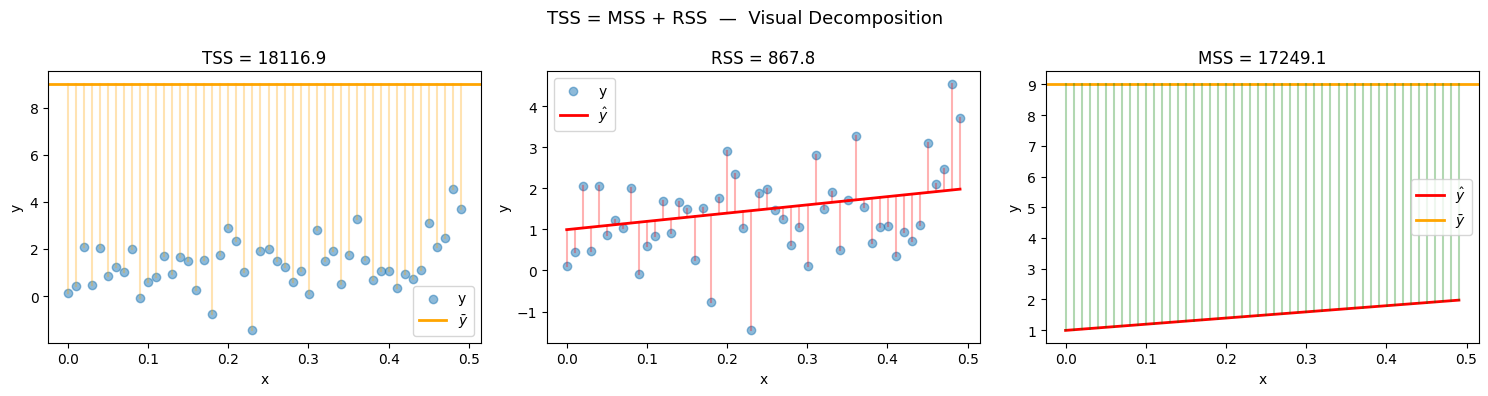

In [6]:
# Visual decomposition: TSS vs RSS vs MSS
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
idx = np.arange(0, 50)  # first 50 points for clarity
y_bar_train = np.mean(y_train)

# TSS
axes[0].scatter(x_train[idx], y_train[idx], alpha=0.5, label='y')
axes[0].axhline(y_bar_train, color='orange', lw=2, label=r'$\bar{y}$')
for i in idx:
    axes[0].plot([x_train[i], x_train[i]], [y_bar_train, y_train[i]], 'orange', alpha=0.3)
axes[0].set_title(f'TSS = {TSS:.1f}'); axes[0].legend()

# RSS
axes[1].scatter(x_train[idx], y_train[idx], alpha=0.5, label='y')
axes[1].plot(x_train[idx], y_pred_train[idx], 'r-', lw=2, label=r'$\hat{y}$')
for i in idx:
    axes[1].plot([x_train[i], x_train[i]], [y_pred_train[i], y_train[i]], 'red', alpha=0.3)
axes[1].set_title(f'RSS = {RSS:.1f}'); axes[1].legend()

# MSS
axes[2].plot(x_train[idx], y_pred_train[idx], 'r-', lw=2, label=r'$\hat{y}$')
axes[2].axhline(y_bar_train, color='orange', lw=2, label=r'$\bar{y}$')
for i in idx:
    axes[2].plot([x_train[i], x_train[i]], [y_bar_train, y_pred_train[i]], 'green', alpha=0.3)
axes[2].set_title(f'MSS = {MSS:.1f}'); axes[2].legend()

for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle('TSS = MSS + RSS  —  Visual Decomposition', fontsize=13)
plt.tight_layout(); plt.show()

Visualization of Projections

TSS = vertical distance from mean

RSS = vertical distance from regression line

MSS = distance between regression line and mean

### 2.1 R² always increases when you add features?

Adding a **pure noise** feature increases $R^2$ on the training set, not a perfect metric

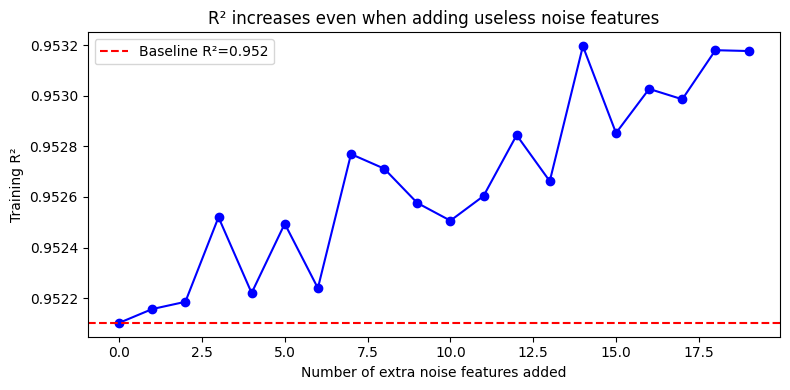

In [7]:
r2_values = []
n_extra_features = range(0, 20)

for k in n_extra_features:
    if k == 0:
        X_aug = X_train
    else:
        noise_features = np.random.randn(len(x_train), k)
        X_aug = np.column_stack([X_train, noise_features])
    
    beta = np.linalg.lstsq(X_aug, y_train, rcond=None)[0]
    y_pred_aug = X_aug @ beta
    _, _, _, r2 = compute_r2_components(y_train, y_pred_aug)
    r2_values.append(r2)

plt.figure(figsize=(8, 4))
plt.plot(list(n_extra_features), r2_values, 'bo-')
plt.xlabel('Number of extra noise features added')
plt.ylabel('Training R²')
plt.title('R² increases even when adding useless noise features')
plt.axhline(r2_values[0], color='red', linestyle='--', label=f'Baseline R²={r2_values[0]:.3f}')
plt.legend(); plt.tight_layout(); plt.show()

---
## Part 3 — Estimating Standard Errors

Under the statistical model $Y = X\beta^* + \varepsilon$, where $\varepsilon_i \overset{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2)$:

- $\hat{\beta}$ is the **MLE** of $\beta^*$ and is **unbiased**: $\mathbb{E}[\hat{\beta}] = \beta^*$
- $\text{Cov}(\hat{\beta}) = \sigma^2 (X^\top X)^{-1}$
- $\sigma^2$ is unknown, but we can estimate it **unbiasedly** via:

$$\hat{\sigma}^2 = \frac{\text{RSS}}{n - p - 1}$$

where $n$ = number of samples, $p$ = number of features (excluding intercept).

The **standard error** of $\hat{\beta}_i$ is:
$$\text{SE}(\hat{\beta}_i) = \sqrt{\hat{\sigma}^2 \cdot C_{ii}}$$

where $C_{ii}$ is the $i$-th diagonal entry of $(X^\top X)^{-1}$.

We can then say $\beta_i^*$ likely lies within $\hat{\beta}_i \pm \text{SE}(\hat{\beta}_i)$.

## Derivation of the standard error

In the multiple linear regression model

$$
Y = X\beta + \varepsilon, \qquad \mathbb{E}[\varepsilon] = 0, \qquad \mathrm{Var}(\varepsilon) = \sigma^2 I
$$

the OLS estimator is

$$
\hat{\beta} = (X^T X)^{-1} X^T Y
$$

The variance–covariance matrix of $\hat{\beta}$ is:

$$
\mathrm{Var}(\hat{\beta}) 
= \mathrm{Var}\left((X^T X)^{-1} X^T Y\right)
$$

$$
= (X^T X)^{-1} X^T \mathrm{Var}(Y) X (X^T X)^{-1}
$$

Since

$$
\mathrm{Var}(Y) = \sigma^2 I
$$

this simplifies to:

$$
\mathrm{Var}(\hat{\beta})
= \sigma^2 (X^T X)^{-1} X^T I X (X^T X)^{-1}
$$

$$
= \sigma^2 (X^T X)^{-1}
$$

---

Now, let

$$
C = (X^T X)^{-1}
$$

The matrix $\mathrm{Var}(\hat{\beta})$ is a $(k+1) \times (k+1)$ matrix whose diagonal elements represent the variances of the individual coefficients.

Specifically,

$$
\mathrm{Var}(\hat{\beta}_i) = \sigma^2 C_{ii}
$$

where $C_{ii}$ is the $i$-th diagonal element of $(X^T X)^{-1}$.

---

Finally, Substitute the Unbiased Estimator for Variance

In practice, the population variance $\sigma^2$ is unknown and is replaced by its unbiased estimator:

$$
\hat{\sigma}^2 = \frac{e^T e}{n - k - 1}
$$

where $e = Y - X\hat{\beta}$ is the residual vector.

The estimated variance of $\hat{\beta}_i$ becomes:

$$
\widehat{\mathrm{Var}}(\hat{\beta}_i) = \hat{\sigma}^2 C_{ii}
$$

In [8]:
def ols_with_standard_errors(X, y):
    """
    Fits OLS and computes:
      - beta_hat
      - sigma2_hat (unbiased estimate of noise variance)
      - standard errors for each coefficient
    """
    n, k = X.shape        # k = p+1 (includes intercept column)
    p = k - 1             # number of features
    
    XTX_inv = np.linalg.inv(X.T @ X)
    beta_hat = XTX_inv @ X.T @ y
    
    y_pred = X @ beta_hat
    residuals = y - y_pred
    
    RSS = np.sum(residuals ** 2)
    sigma2_hat = RSS / (n - p - 1)    # unbiased estimator
    
    # Variance of each coefficient = sigma2 * diagonal of (X'X)^-1
    var_beta = sigma2_hat * np.diag(XTX_inv)
    se_beta  = np.sqrt(var_beta)
    
    return beta_hat, sigma2_hat, se_beta, RSS


beta_hat, sigma2_hat, se_beta, RSS = ols_with_standard_errors(X_train, y_train)

print("=== OLS Estimates with Standard Errors ===")
print(f"  sigma² estimate (σ̂²) = {sigma2_hat:.4f}   (true = 1.0)")
print()
labels = ['Intercept', 'Slope (x)']
for i, (b, se, label) in enumerate(zip(beta_hat, se_beta, labels)):
    print(f"  {label:20s}: β̂ = {b:.4f},  SE = {se:.4f},  95% CI ≈ ({b-2*se:.4f}, {b+2*se:.4f})")

=== OLS Estimates with Standard Errors ===
  sigma² estimate (σ̂²) = 1.0874   (true = 1.0)

  Intercept           : β̂ = 0.9920,  SE = 0.0737,  95% CI ≈ (0.8447, 1.1394)
  Slope (x)           : β̂ = 2.0087,  SE = 0.0159,  95% CI ≈ (1.9768, 2.0405)


---
## Part 4 — Hypothesis Testing

**Question:** Is feature $i$ actually useful for predicting $Y$?

We frame this as a hypothesis test:
- $H_0$: $\beta_i^* = 0$ (feature has no effect)
- $H_a$: $\beta_i^* \neq 0$ (feature has an effect)

**4 Steps:**
1. Define $H_0$ and $H_a$
2. Compute the test statistic: $t_i = \dfrac{\hat{\beta}_i}{\text{SE}(\hat{\beta}_i)} \sim \mathcal{N}(0,1)$ under $H_0$
3. Compute the **p-value** = probability of seeing a $|t|$ at least this large under $H_0$
4. Reject $H_0$ if p-value $< 0.05$ (or chosen threshold $\alpha$)

> A **small p-value** means the observed test statistic is very unlikely under $H_0$, providing evidence against $H_0$.

> **Note:** The framework is asymmetric. Failing to reject $H_0$ does not mean $H_0$ is true — we may simply lack enough data.

Normal distribution vs t distribution - for finite samples eventhough normal distribution used in formula

In [9]:
def hypothesis_test(beta_hat, se_beta, n, p):
    """
    For each coefficient, compute t-statistic and two-sided p-value.
    t ~ N(0,1) approximately (or t-distribution with n-p-1 df).
    """
    df = n - p - 1
    t_stats = beta_hat / se_beta
    # Two-sided p-value using t-distribution
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=df))
    return t_stats, p_values


n_train = len(y_train)
p_features = 1  # one feature (slope)
t_stats, p_values = hypothesis_test(beta_hat, se_beta, n_train, p_features)

print("=== Hypothesis Test: H0: β_i = 0 ===")
print(f"{'Parameter':<20} {'β̂':>10} {'SE':>10} {'t-stat':>10} {'p-value':>12} {'Reject H0?':>12}")
print("-" * 76)
for label, b, se, t, pv in zip(labels, beta_hat, se_beta, t_stats, p_values):
    reject = "Yes ✓" if pv < 0.05 else "No"
    pv_str = f"{pv:.4e}" if pv < 0.001 else f"{pv:.4f}"
    print(f"{label:<20} {b:>10.4f} {se:>10.4f} {t:>10.4f} {pv_str:>12} {reject:>12}")

=== Hypothesis Test: H0: β_i = 0 ===
Parameter                    β̂         SE     t-stat      p-value   Reject H0?
----------------------------------------------------------------------------
Intercept                0.9920     0.0737    13.4663   0.0000e+00        Yes ✓
Slope (x)                2.0087     0.0159   125.9463   0.0000e+00        Yes ✓


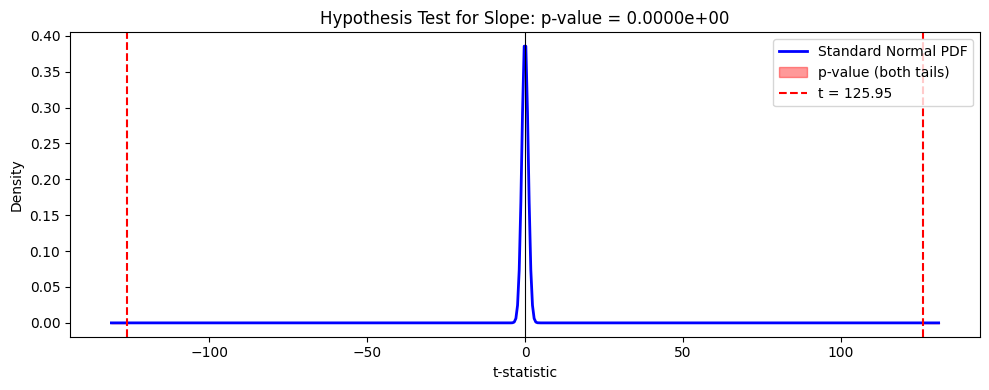

In [10]:
# Visualise the p-value for the slope coefficient
t_slope = t_stats[1]
df = n_train - p_features - 1

t_range = np.linspace(-abs(t_slope) - 5, abs(t_slope) + 5, 500)
pdf = stats.norm.pdf(t_range)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_range, pdf, 'b-', lw=2, label='Standard Normal PDF')
ax.fill_between(t_range, pdf, where=(t_range >= abs(t_slope)), color='red', alpha=0.4, label='p-value (both tails)')
ax.fill_between(t_range, pdf, where=(t_range <= -abs(t_slope)), color='red', alpha=0.4)
ax.axvline(t_slope,  color='red',   linestyle='--', label=f't = {t_slope:.2f}')
ax.axvline(-t_slope, color='red',   linestyle='--')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('t-statistic'); ax.set_ylabel('Density')
ax.set_title(f'Hypothesis Test for Slope: p-value = {p_values[1]:.4e}')
ax.legend(); plt.tight_layout(); plt.show()

Same graph present in ecture notes, find the t statistic and then the corresponding AUC will give required p-value

---
## 5: Application on Advertising Dataset

The advertising dataset has 200 markets. For each market:
- **Features:** TV, Radio, Newspaper advertising budgets (in $1000s)
- **Target:** Sales (in 1000 units)

We'll use this dataset to demonstrate everything from scratch: OLS fit, R², standard errors, and hypothesis testing — just as shown in lectures.

In [11]:
# Recreate the Advertising dataset (same structure as in lecture)
# We generate a synthetic version matching the lecture statistics closely
np.random.seed(0)
n_markets = 200

TV        = np.random.uniform(0.7, 296.4, n_markets)
Radio     = np.random.uniform(0.0,  49.6, n_markets)
Newspaper = np.random.uniform(0.3, 114.0, n_markets)

# True model from lecture: sales = 2.939 + 0.046*TV + 0.189*Radio - 0.001*Newspaper + noise
Sales = (2.939
         + 0.046  * TV
         + 0.189  * Radio
         - 0.001  * Newspaper
         + np.random.randn(n_markets) * 1.7)

adv_df = pd.DataFrame({'TV': TV, 'Radio': Radio, 'Newspaper': Newspaper, 'Sales': Sales})
print(adv_df.describe().round(3))

            TV    Radio  Newspaper    Sales
count  200.000  200.000    200.000  200.000
mean   148.679   24.363     57.488   14.087
std     84.164   14.612     34.331    4.733
min      2.088    0.567      0.607    3.240
25%     75.263   11.935     28.874   10.477
50%    160.454   22.901     52.948   13.821
75%    212.266   37.556     85.489   17.412
max    296.059   49.121    113.768   24.915


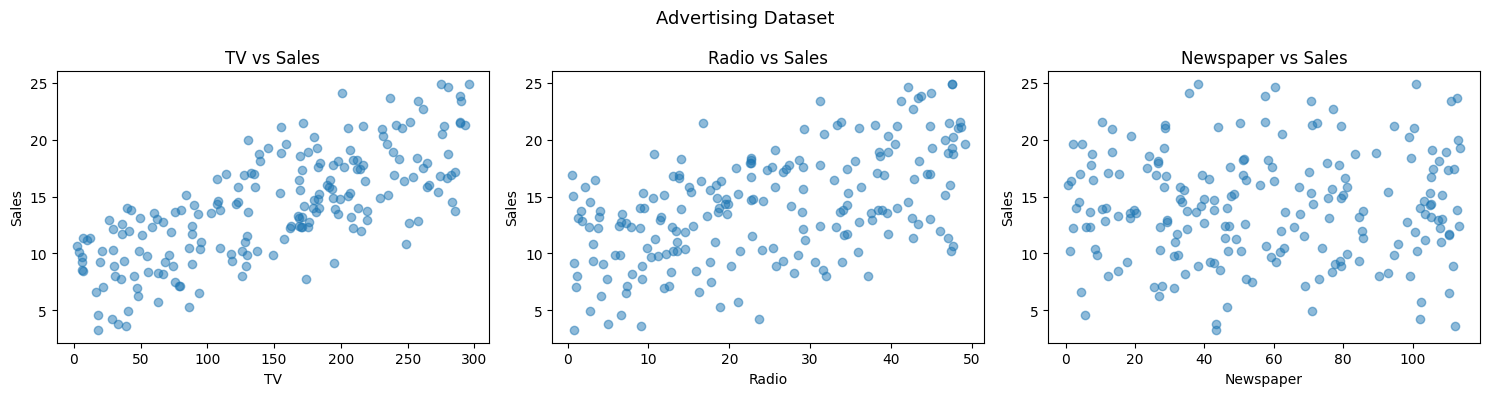

In [12]:
# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, ['TV', 'Radio', 'Newspaper']):
    ax.scatter(adv_df[feat], adv_df['Sales'], alpha=0.5)
    ax.set_xlabel(feat); ax.set_ylabel('Sales')
    ax.set_title(f'{feat} vs Sales')
plt.suptitle('Advertising Dataset', fontsize=13)
plt.tight_layout(); plt.show()

### 5.1 Simple Linear Regression: TV → Sales

In [13]:
# Build X for simple regression (intercept + TV)
X_tv = np.column_stack([np.ones(n_markets), adv_df['TV'].values])
y_sales = adv_df['Sales'].values

beta_tv, sigma2_tv, se_tv, rss_tv = ols_with_standard_errors(X_tv, y_sales)
t_tv, pv_tv = hypothesis_test(beta_tv, se_tv, n_markets, p=1)

TSS_tv, RSS_tv, MSS_tv, R2_tv = compute_r2_components(y_sales, X_tv @ beta_tv)

print("=== Simple Regression: Sales ~ TV ===")
print(f"{'Parameter':<12} {'Coef':>8} {'Std Err':>10} {'t-stat':>10} {'p-value':>12}")
print("-" * 55)
for label, b, se, t, pv in zip(['Intercept','TV'], beta_tv, se_tv, t_tv, pv_tv):
    pv_str = "< 0.0001" if pv < 0.0001 else f"{pv:.4f}"
    print(f"{label:<12} {b:>8.4f} {se:>10.4f} {t:>10.2f} {pv_str:>12}")
print()
print(f"  R² = {R2_tv:.4f}")
print(f"  σ̂² = {sigma2_tv:.4f}")

=== Simple Regression: Sales ~ TV ===
Parameter        Coef    Std Err     t-stat      p-value
-------------------------------------------------------
Intercept      7.9364     0.4623      17.17     < 0.0001
TV             0.0414     0.0027      15.28     < 0.0001

  R² = 0.5412
  σ̂² = 10.3319


### 5.2 Multiple Linear Regression: TV + Radio + Newspaper → Sales

In [14]:
# Build X for multiple regression
X_multi = np.column_stack([
    np.ones(n_markets),
    adv_df['TV'].values,
    adv_df['Radio'].values,
    adv_df['Newspaper'].values
])

beta_multi, sigma2_multi, se_multi, rss_multi = ols_with_standard_errors(X_multi, y_sales)
t_multi, pv_multi = hypothesis_test(beta_multi, se_multi, n_markets, p=3)
TSS_m, RSS_m, MSS_m, R2_m = compute_r2_components(y_sales, X_multi @ beta_multi)

print("=== Multiple Regression: Sales ~ TV + Radio + Newspaper ===")
print(f"{'Parameter':<14} {'Coef':>8} {'Std Err':>10} {'t-stat':>10} {'p-value':>12} {'Significant':>12}")
print("-" * 70)
feat_labels = ['Intercept', 'TV', 'Radio', 'Newspaper']
for label, b, se, t, pv in zip(feat_labels, beta_multi, se_multi, t_multi, pv_multi):
    pv_str  = "< 0.0001" if pv < 0.0001 else f"{pv:.4f}"
    sig_str = "***" if pv < 0.001 else ("**" if pv < 0.01 else ("*" if pv < 0.05 else ""))
    print(f"{label:<14} {b:>8.4f} {se:>10.4f} {t:>10.2f} {pv_str:>12} {sig_str:>12}")

print()
print(f"  R² = {R2_m:.4f}")
print(f"  σ̂² = {sigma2_multi:.4f}")

=== Multiple Regression: Sales ~ TV + Radio + Newspaper ===
Parameter          Coef    Std Err     t-stat      p-value  Significant
----------------------------------------------------------------------
Intercept        3.1063     0.3819       8.13     < 0.0001          ***
TV               0.0431     0.0014      29.78     < 0.0001          ***
Radio            0.1861     0.0084      22.28     < 0.0001          ***
Newspaper        0.0006     0.0036       0.17       0.8643             

  R² = 0.8704
  σ̂² = 2.9478


### 5.3 Interpretation of the Multiple Regression Results

Notice the role of the **Newspaper** coefficient:
- In isolation, newspaper spending *is* correlated with sales.
- But once TV and Radio are controlled for, the Newspaper coefficient becomes near zero with a **large p-value** (0.86 in lecture).
- We **fail to reject** $H_0: \beta_{\text{newspaper}}^* = 0$.

Let's verify this by looking at correlations.

In [15]:
corr_matrix = adv_df.corr().round(4)
print("Correlation matrix:")
print(corr_matrix)
print()
print("Note: Newspaper is correlated with Radio (which drives sales),")
print("but once Radio is in the model, Newspaper adds no information.")

Correlation matrix:
               TV   Radio  Newspaper   Sales
TV         1.0000 -0.0544    -0.0177  0.7356
Radio     -0.0544  1.0000     0.0528  0.5329
Newspaper -0.0177  0.0528     1.0000  0.0212
Sales      0.7356  0.5329     0.0212  1.0000

Note: Newspaper is correlated with Radio (which drives sales),
but once Radio is in the model, Newspaper adds no information.


In [16]:
# Compare R² across models
_, _, _, r2_tv_only  = compute_r2_components(y_sales, X_tv @ beta_tv)

X_tv_radio = np.column_stack([np.ones(n_markets), adv_df['TV'].values, adv_df['Radio'].values])
beta_tv_radio = np.linalg.lstsq(X_tv_radio, y_sales, rcond=None)[0]
_, _, _, r2_tv_radio = compute_r2_components(y_sales, X_tv_radio @ beta_tv_radio)

print("R² comparison across models:")
print(f"  TV only            : R² = {r2_tv_only:.4f}")
print(f"  TV + Radio         : R² = {r2_tv_radio:.4f}")
print(f"  TV + Radio + Paper : R² = {R2_m:.4f}")
print()

R² comparison across models:
  TV only            : R² = 0.5412
  TV + Radio         : R² = 0.8704
  TV + Radio + Paper : R² = 0.8704



Adding Newspaper barely improves R² — consistent with its large p-value.

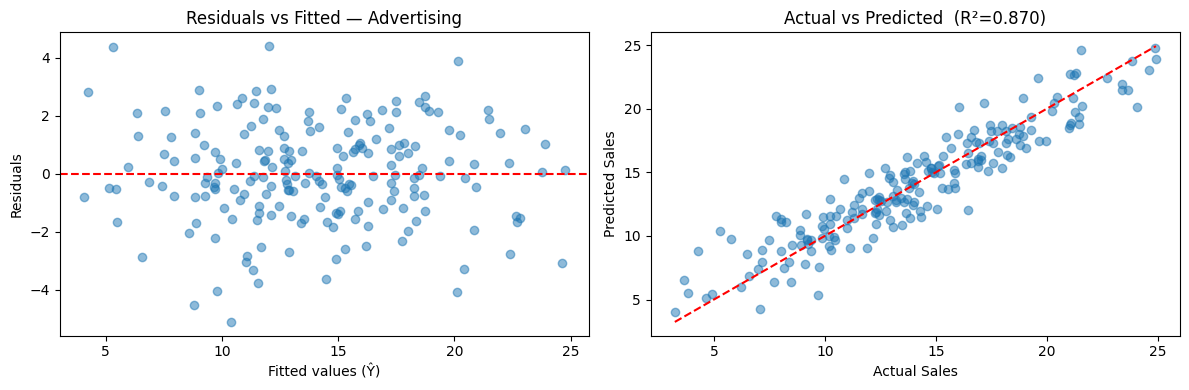

In [17]:
# Residual plot for the full model
y_pred_multi = X_multi @ beta_multi
residuals_multi = y_sales - y_pred_multi

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_multi, residuals_multi, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values (Ŷ)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted — Advertising')

axes[1].scatter(y_sales, y_pred_multi, alpha=0.5)
axes[1].plot([y_sales.min(), y_sales.max()], [y_sales.min(), y_sales.max()], 'r--')
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')
axes[1].set_title(f'Actual vs Predicted  (R²={R2_m:.3f})')

plt.tight_layout(); plt.show()

---
## 6 Application on Diabetes Dataset

The full evaluation pipeline — OLS, R², standard errors, hypothesis testing — to the real **Diabetes dataset** from sklearn is applied directly, implementation heavy exercise

In [18]:
# Load diabetes dataset
diabetes = load_diabetes()
X_d = diabetes.data
y_d = diabetes.target
feature_names = list(diabetes.feature_names)

print('Feature names:', feature_names)
print('X shape:', X_d.shape)
print('y shape:', y_d.shape)
print('Target = disease progression score (higher = worse)')

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X shape: (442, 10)
y shape: (442,)
Target = disease progression score (higher = worse)


In [19]:
# Train-test split
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_d, y_d, test_size=0.3, random_state=42
)

# Add intercept column
X_d_train_int = np.column_stack([np.ones(len(y_d_train)), X_d_train])
X_d_test_int  = np.column_stack([np.ones(len(y_d_test)),  X_d_test])

# Fit OLS with full evaluation
n_d, p_d = X_d_train.shape
beta_d, sigma2_d, se_d, rss_d = ols_with_standard_errors(X_d_train_int, y_d_train)
t_d, pv_d = hypothesis_test(beta_d, se_d, n_d, p_d)
_, _, _, R2_d_train = compute_r2_components(y_d_train, X_d_train_int @ beta_d)
_, _, _, R2_d_test  = compute_r2_components(y_d_test,  X_d_test_int  @ beta_d)

print(f"\nTraining R² = {R2_d_train:.4f}")
print(f"Test R²     = {R2_d_test:.4f}")
print(f"σ̂²          = {sigma2_d:.2f}")


Training R² = 0.5244
Test R²     = 0.4773
σ̂²          = 3031.98


In [20]:
# Full regression table for diabetes
print("=== Diabetes Dataset — Full Regression Table ===")
print(f"{'Feature':<14} {'Coef':>10} {'Std Err':>10} {'t-stat':>10} {'p-value':>12} {'Sig':>6}")
print("-" * 65)
all_labels = ['Intercept'] + feature_names
for label, b, se, t, pv in zip(all_labels, beta_d, se_d, t_d, pv_d):
    pv_str  = "< 0.0001" if pv < 0.0001 else f"{pv:.4f}"
    sig_str = "***" if pv < 0.001 else ("**" if pv < 0.01 else ("*" if pv < 0.05 else ""))
    print(f"{label:<14} {b:>10.3f} {se:>10.3f} {t:>10.2f} {pv_str:>12} {sig_str:>6}")
print()
print("Significance codes: *** p<0.001  ** p<0.01  * p<0.05")

=== Diabetes Dataset — Full Regression Table ===
Feature              Coef    Std Err     t-stat      p-value    Sig
-----------------------------------------------------------------
Intercept         151.008      3.143      48.05     < 0.0001    ***
age                29.254     74.280       0.39       0.6940       
sex              -261.706     73.301      -3.57       0.0004    ***
bmi               546.300     81.326       6.72     < 0.0001    ***
bp                388.398     77.707       5.00     < 0.0001    ***
s1               -901.960    479.190      -1.88       0.0608       
s2                506.763    385.746       1.31       0.1900       
s3                121.154    245.611       0.49       0.6222       
s4                288.035    196.608       1.47       0.1440       
s5                659.269    207.907       3.17       0.0017     **
s6                 41.377     79.783       0.52       0.6044       

Significance codes: *** p<0.001  ** p<0.01  * p<0.05


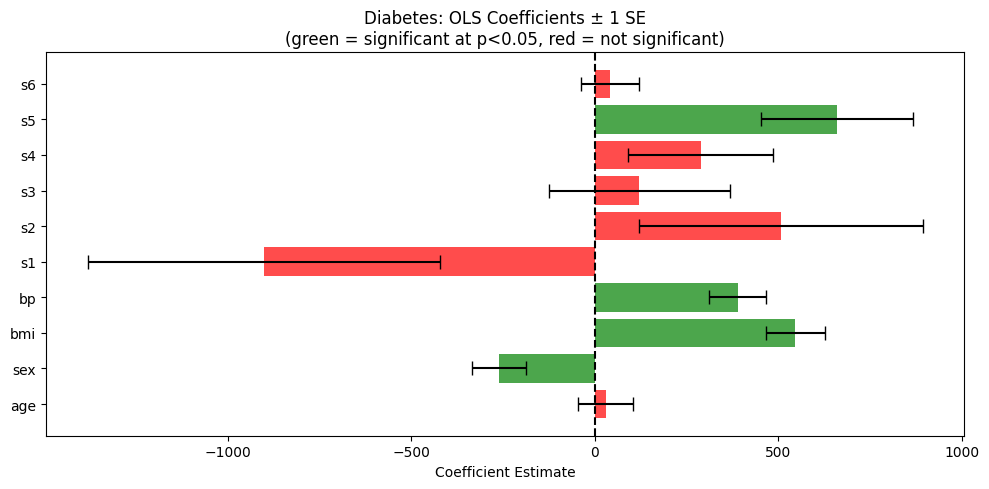

In [21]:
# Plot: coefficient estimates with ±1 SE error bars
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(feature_names))
coefs = beta_d[1:]     # skip intercept
ses   = se_d[1:]       # skip intercept

colors = ['green' if pv_d[i+1] < 0.05 else 'red' for i in range(len(feature_names))]

ax.barh(x_pos, coefs, xerr=ses, color=colors, alpha=0.7, capsize=5)
ax.axvline(0, color='black', lw=1.5, linestyle='--')
ax.set_yticks(x_pos); ax.set_yticklabels(feature_names)
ax.set_xlabel('Coefficient Estimate')
ax.set_title('Diabetes: OLS Coefficients ± 1 SE\n(green = significant at p<0.05, red = not significant)')
plt.tight_layout(); plt.show()

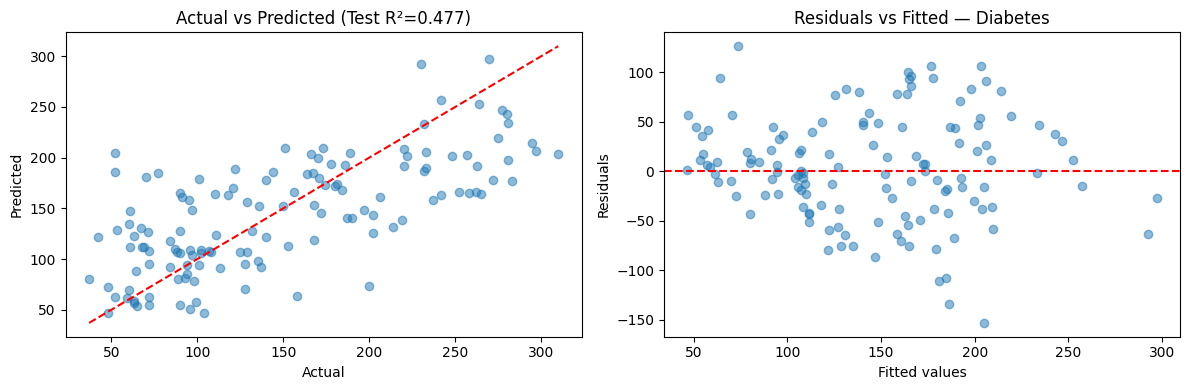

In [22]:
# Actual vs Predicted on test set
y_d_pred_test = X_d_test_int @ beta_d

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_d_test, y_d_pred_test, alpha=0.5)
axes[0].plot([y_d_test.min(), y_d_test.max()], [y_d_test.min(), y_d_test.max()], 'r--')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Actual vs Predicted (Test R²={R2_d_test:.3f})')

residuals_d = y_d_test - y_d_pred_test
axes[1].scatter(y_d_pred_test, residuals_d, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted values'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Fitted — Diabetes')

plt.tight_layout(); plt.show()

---
## Summary

| Concept | Formula | Python |
|---|---|---|
| OLS estimator | $\hat{\beta} = (X^\top X)^{-1} X^\top Y$ | `np.linalg.inv(X.T @ X) @ X.T @ y` |
| Hat matrix | $H = X(X^\top X)^{-1}X^\top$ | — |
| TSS | $\sum(y_i - \bar{y})^2$ | `np.sum((y - y.mean())**2)` |
| RSS | $\sum(y_i - \hat{y}_i)^2$ | `np.sum((y - y_pred)**2)` |
| MSS | TSS − RSS | — |
| R² | $1 - \text{RSS}/\text{TSS}$ | `r2_score(y, y_pred)` |
| Noise variance | $\hat{\sigma}^2 = \text{RSS}/(n-p-1)$ | — |
| SE of $\hat{\beta}_i$ | $\sqrt{\hat{\sigma}^2 C_{ii}}$ | — |
| t-statistic | $\hat{\beta}_i / \text{SE}(\hat{\beta}_i)$ | — |
| p-value | $2 P(|T| \geq |t|)$ under $H_0$ | `scipy.stats.t.cdf` |

**Key takeaways:**
- OLS is the MLE under Gaussian noise and is **unbiased**.
- R² measures the fraction of output variance explained — but always increases with more features.
- Hypothesis tests tell us whether each feature is **statistically significantly** associated with the output.
- The Newspaper coefficient in advertising shows how correlated predictors can confound simple interpretations.